# O2 A Plot Accessor Demo

This notebook is a catalog of the supported plotting surface: `.plot` accessors on zdisamar domain objects. Each plot is displayed in its own cell.


## Setup

The setup creates one O2 A case, runs the RTM diagnostics, and stores one SVG chart per public accessor method.


In [1]:
import sys
from pathlib import Path
from time import perf_counter


def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "validation").is_dir():
            return candidate
    raise RuntimeError("open this notebook from inside the zdisamar checkout")


REPO_ROOT = find_repo_root()
sys.path[:0] = [str(REPO_ROOT), str(REPO_ROOT / "python")]

from zdisamar import rtm  # noqa: E402
from zdisamar.wavelength_bands import o2a  # noqa: E402

from validation.o2a import baseline as oe_baseline  # noqa: E402
from validation.o2a.measurement_noise import components_from_spectrum  # noqa: E402


def show_timed_plot(label, factory):
    start = perf_counter()
    chart = factory()
    elapsed_ms = (perf_counter() - start) * 1000.0
    print(f"{label}: {elapsed_ms:.2f} ms")
    return chart


O2A_MARKERS_NM = (
    oe_baseline.WAVELENGTH_START_NM,
    760.76,
    oe_baseline.WAVELENGTH_END_NM,
)


def spectral_grid(case) -> list[float]:
    start = float(case.spectral_grid.start_nm)
    end = float(case.spectral_grid.end_nm)
    count = int(case.spectral_grid.sample_count)
    if count == 1:
        return [start]
    step = (end - start) / float(count - 1)
    return [start + step * index for index in range(count)]


def nearest_grid_values(grid: list[float], targets_nm: tuple[float, ...]) -> list[float]:
    values = []
    for target in targets_nm:
        nearest = min(grid, key=lambda value: abs(value - target))
        if nearest not in values:
            values.append(nearest)
    return values


def response_grid_values(grid: list[float]) -> list[float]:
    values = grid[::35] + nearest_grid_values(grid, O2A_MARKERS_NM)
    return sorted(set(values))

## Build The Data


In [2]:
case = o2a.reference_scene()
oe_baseline.configure_case(case)
grid = spectral_grid(case)
profile_wavelengths_nm = nearest_grid_values(grid, O2A_MARKERS_NM)
response_wavelengths_nm = response_grid_values(grid)

spectrum = rtm.spectrum(case, jacobian=True)
noise = components_from_spectrum(
    wavelength_nm=spectrum.wavelength_nm.copy(),
    radiance=spectrum.radiance.copy(),
    irradiance=spectrum.irradiance.copy(),
    reflectance=spectrum.reflectance.copy(),
)
noise_table = noise.snr_table()
budget = rtm.atmospheric_budget(case, wavelengths_nm=grid)
cia = rtm.collision_induced_absorption(case, wavelengths_nm=grid)
response = rtm.instrument_response(case, wavelengths_nm=response_wavelengths_nm)

## Reflectance


spectrum.plot.reflectance(): 0.78 ms


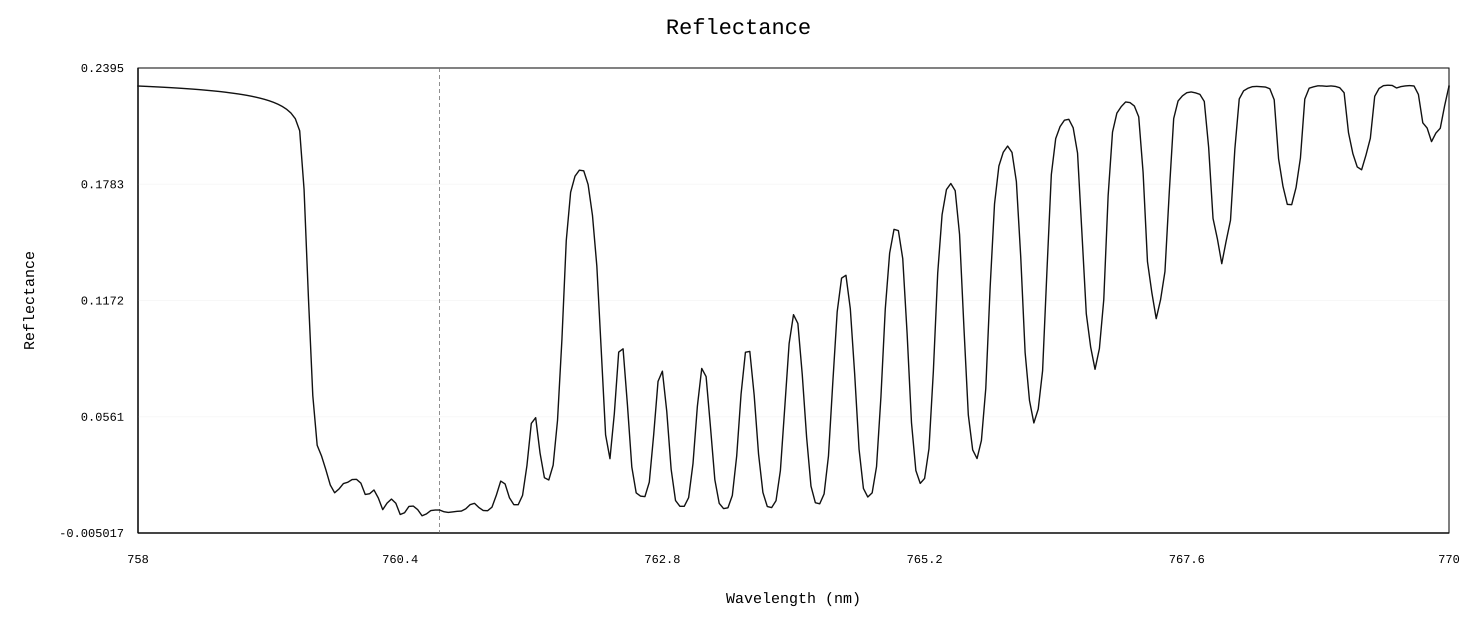

In [3]:
reflectance_chart = show_timed_plot("spectrum.plot.reflectance()", spectrum.plot.reflectance)
reflectance_chart

## Radiance


spectrum.plot.radiance(): 0.38 ms


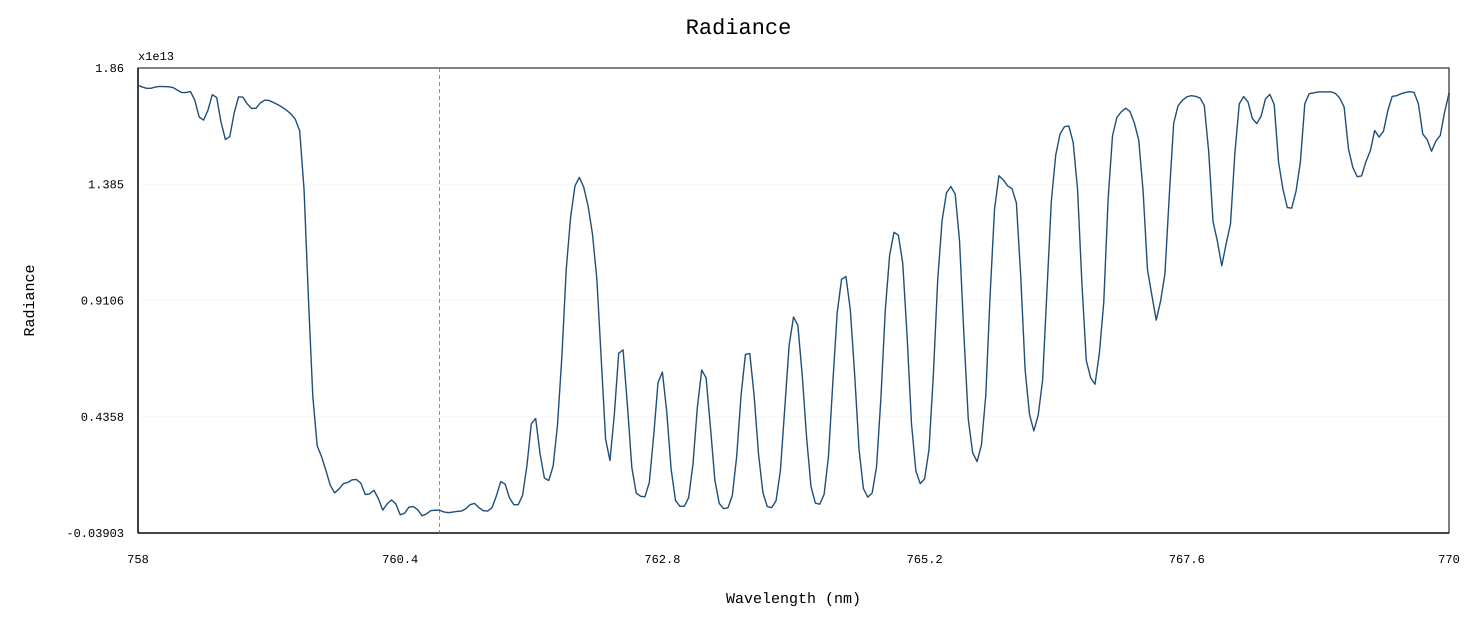

In [4]:
radiance_chart = show_timed_plot("spectrum.plot.radiance()", spectrum.plot.radiance)
radiance_chart

## Irradiance


spectrum.plot.irradiance(): 0.34 ms


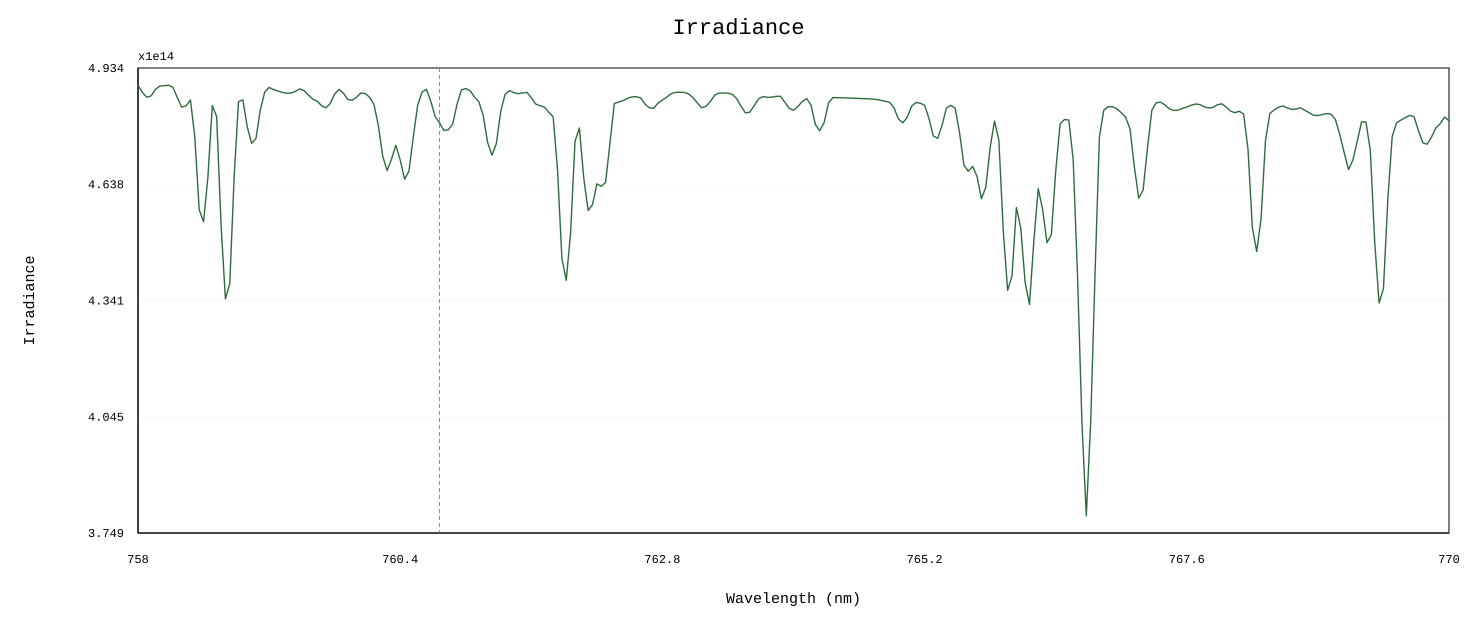

In [5]:
irradiance_chart = show_timed_plot("spectrum.plot.irradiance()", spectrum.plot.irradiance)
irradiance_chart

## Sun-Normalized Radiance


spectrum.plot.sun_normalized_radiance(): 0.35 ms


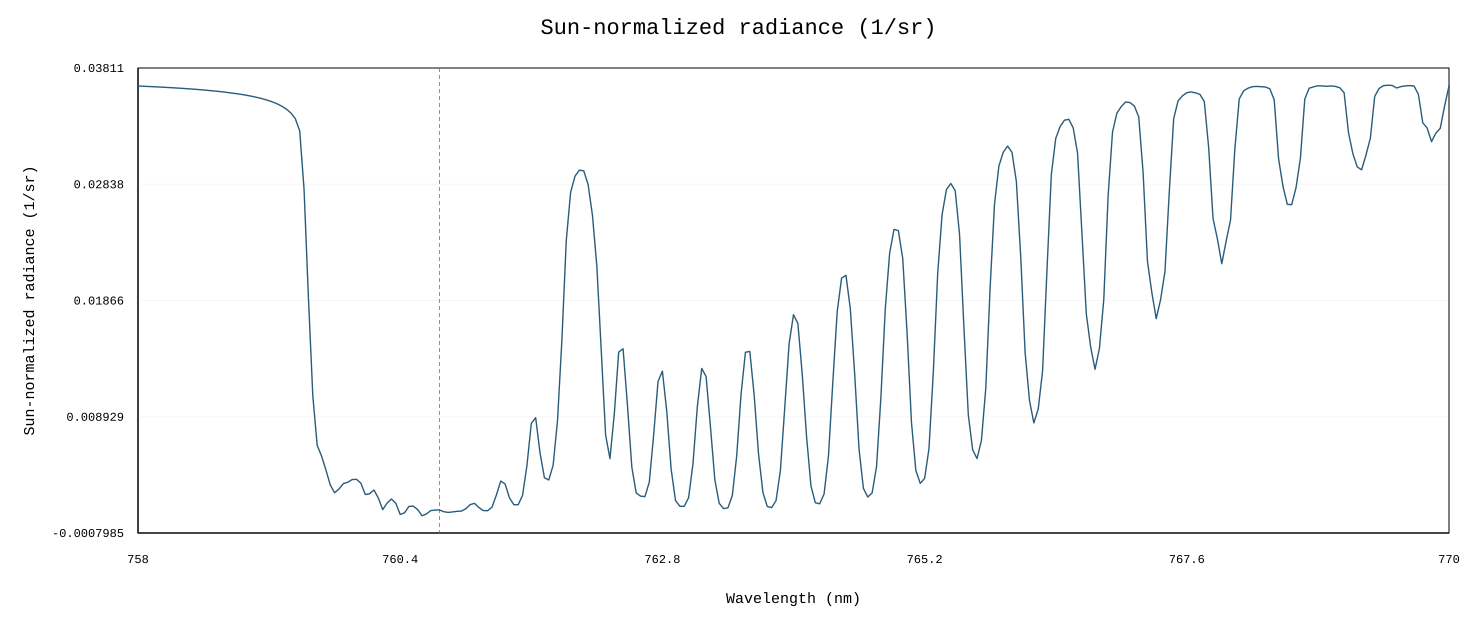

In [6]:
sun_normalized_radiance_chart = show_timed_plot(
    "spectrum.plot.sun_normalized_radiance()",
    spectrum.plot.sun_normalized_radiance,
)
sun_normalized_radiance_chart

## Reflectance Jacobian


spectrum.plot.jacobian(state="aerosol_optical_depth"): 2.16 ms


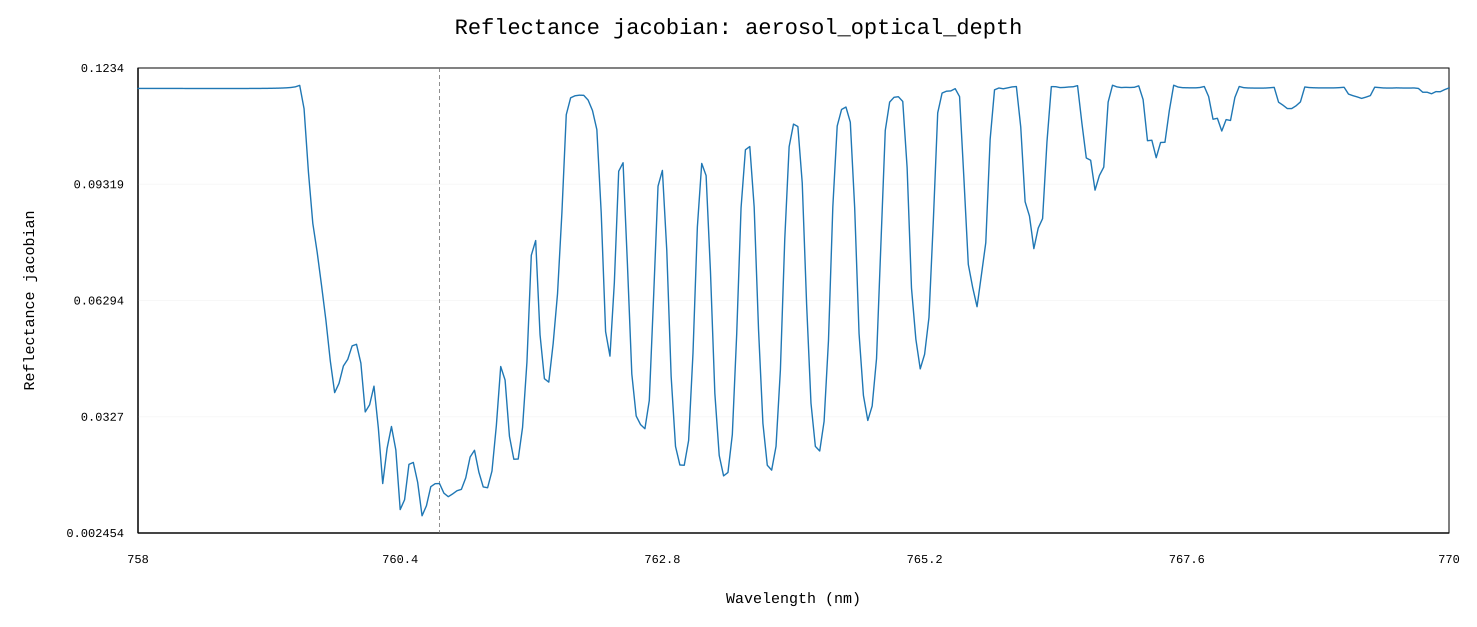

In [7]:
aerosol_jacobian_chart = show_timed_plot(
    'spectrum.plot.jacobian(state="aerosol_optical_depth")',
    lambda: spectrum.plot.jacobian(state="aerosol_optical_depth"),
)
aerosol_jacobian_chart

## Signal-To-Noise Ratio


spectrum.plot.snr(noise_table): 4.33 ms


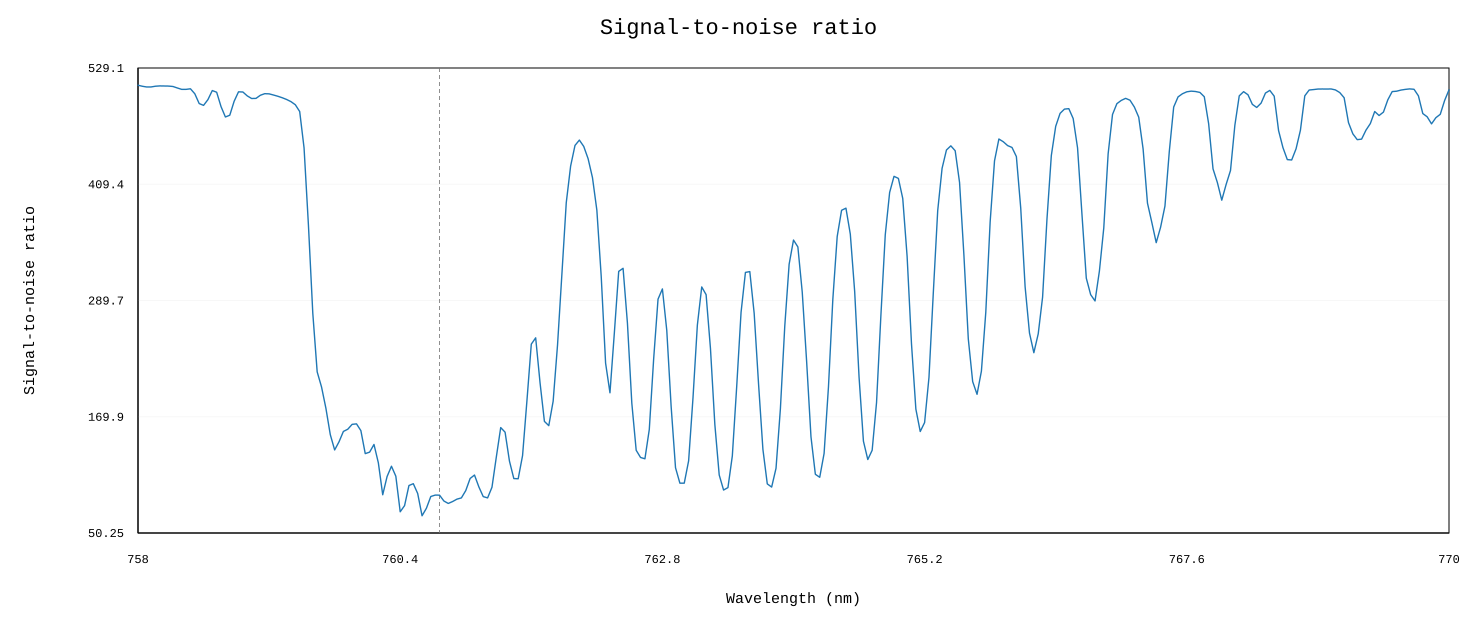

In [8]:
snr_chart = show_timed_plot(
    "spectrum.plot.snr(noise_table)", lambda: spectrum.plot.snr(noise_table)
)
snr_chart

## Noise Envelope


spectrum.plot.noise_envelope(noise_table): 2.39 ms


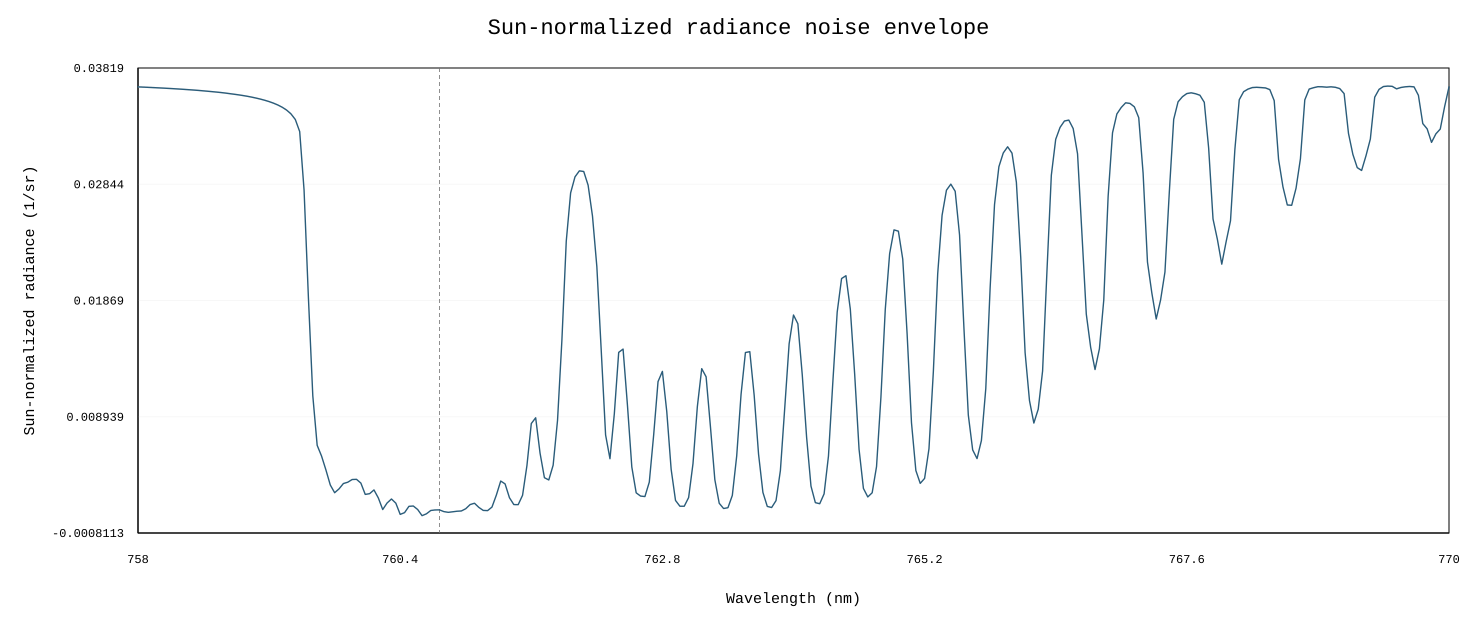

In [9]:
noise_envelope_chart = show_timed_plot(
    "spectrum.plot.noise_envelope(noise_table)",
    lambda: spectrum.plot.noise_envelope(noise_table),
)
noise_envelope_chart

## Atmospheric Optical Depth


budget.plot.optical_depth(): 633.10 ms


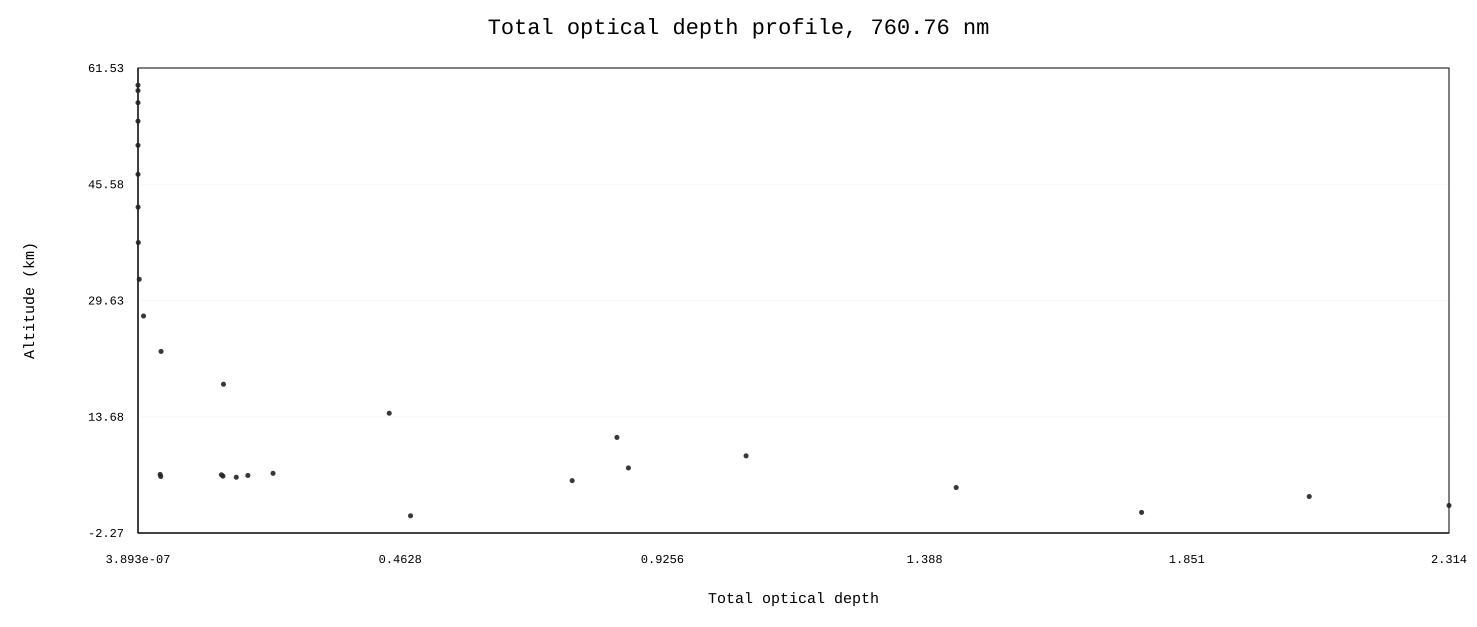

In [10]:
optical_depth_chart = show_timed_plot("budget.plot.optical_depth()", budget.plot.optical_depth)
optical_depth_chart

## O2-O2 CIA Optical Depth


cia.plot.optical_depth(): 302.26 ms


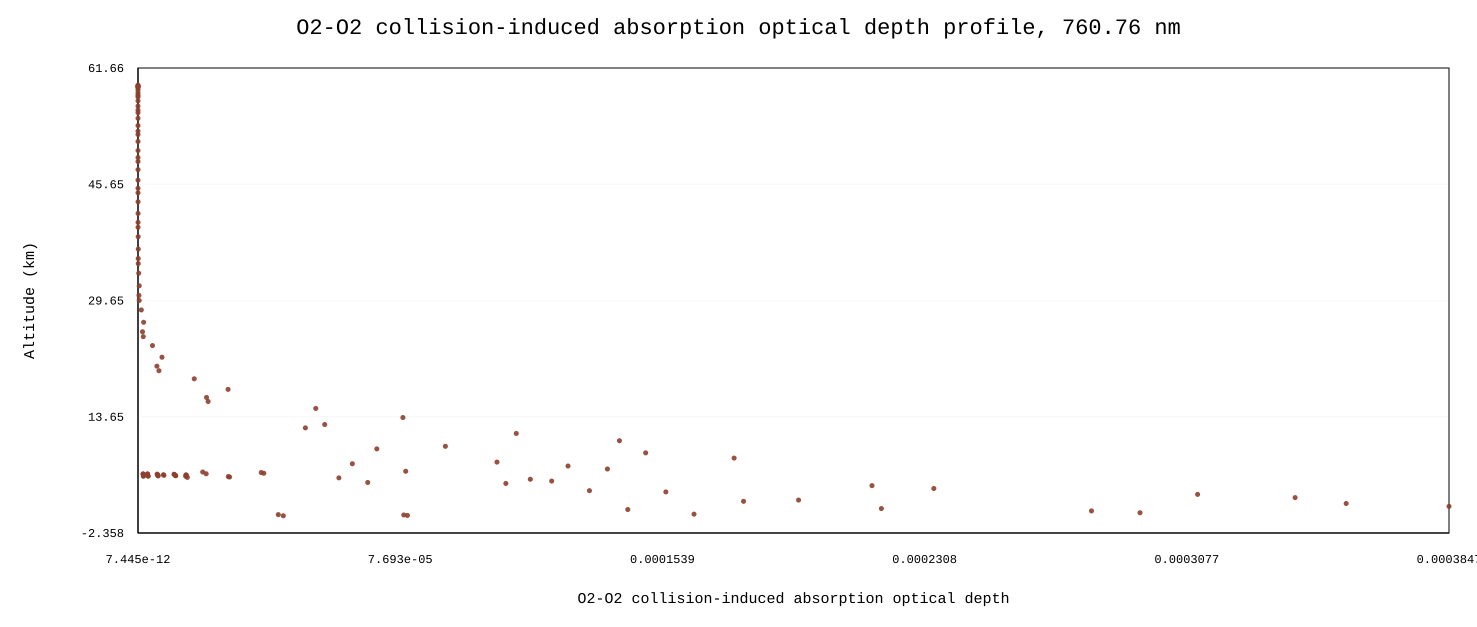

In [11]:
cia_optical_depth_chart = show_timed_plot(
    "cia.plot.optical_depth()",
    cia.plot.optical_depth,
)
cia_optical_depth_chart

## ISRF Curve


response.plot.curve(): 45.84 ms


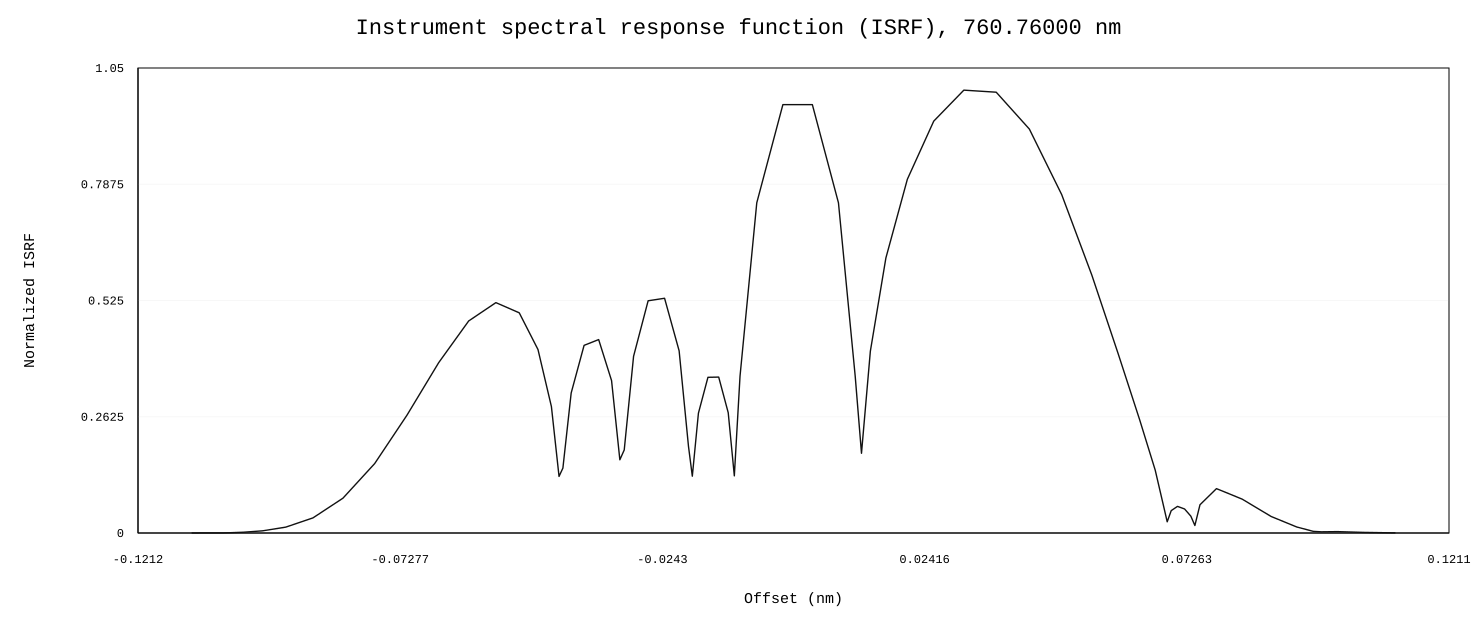

In [12]:
isrf_chart = show_timed_plot("response.plot.curve()", response.plot.curve)
isrf_chart